In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Imports successful")

Imports successful


In [2]:
BASE_DIR = r"D:\diabetic"

DATASET_DIR = os.path.join(BASE_DIR, "dataset")
TRAIN_DIR = os.path.join(DATASET_DIR, "train_images")

TRAIN_CSV = os.path.join(DATASET_DIR, "train.csv")
TEST_CSV = os.path.join(DATASET_DIR, "test.csv")

In [3]:
df = pd.read_csv(TRAIN_CSV)

df.head()


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (3662, 2)

Columns:
['id_code', 'diagnosis']

Data types:
id_code        str
diagnosis    int64
dtype: object


In [5]:
df.isnull().sum()

id_code      0
diagnosis    0
dtype: int64

In [9]:
df["diagnosis"].unique()

array([2, 4, 1, 0, 3])

In [10]:
df["diagnosis"].value_counts().sort_index()

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

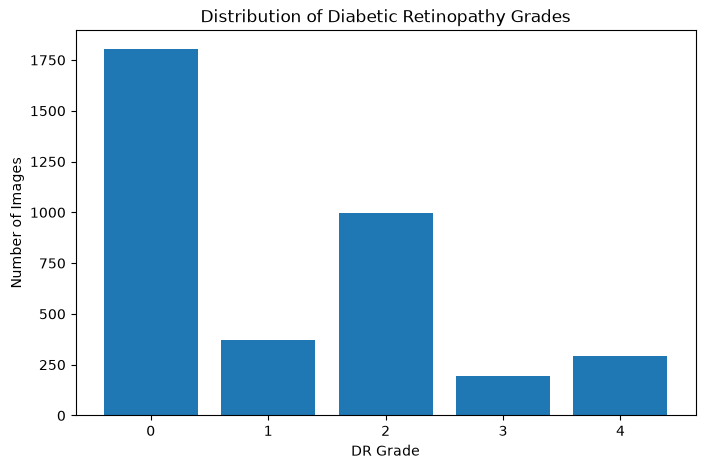

In [11]:
class_counts = df["diagnosis"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("Distribution of Diabetic Retinopathy Grades")

plt.xticks(range(5))

plt.show()

Image ID: 000c1434d8d7
Diagnosis: 2
Image size: (3216, 2136)
Image mode: RGB


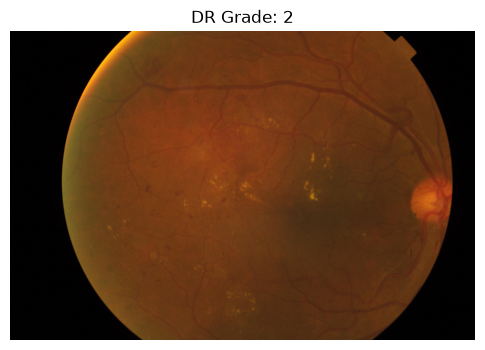

In [12]:
image_id = df.iloc[0]["id_code"]
diagnosis = df.iloc[0]["diagnosis"]

image_path = os.path.join(TRAIN_DIR, image_id + ".png")

image = Image.open(image_path)

print("Image ID:", image_id)
print("Diagnosis:", diagnosis)
print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"DR Grade: {diagnosis}")
plt.show()

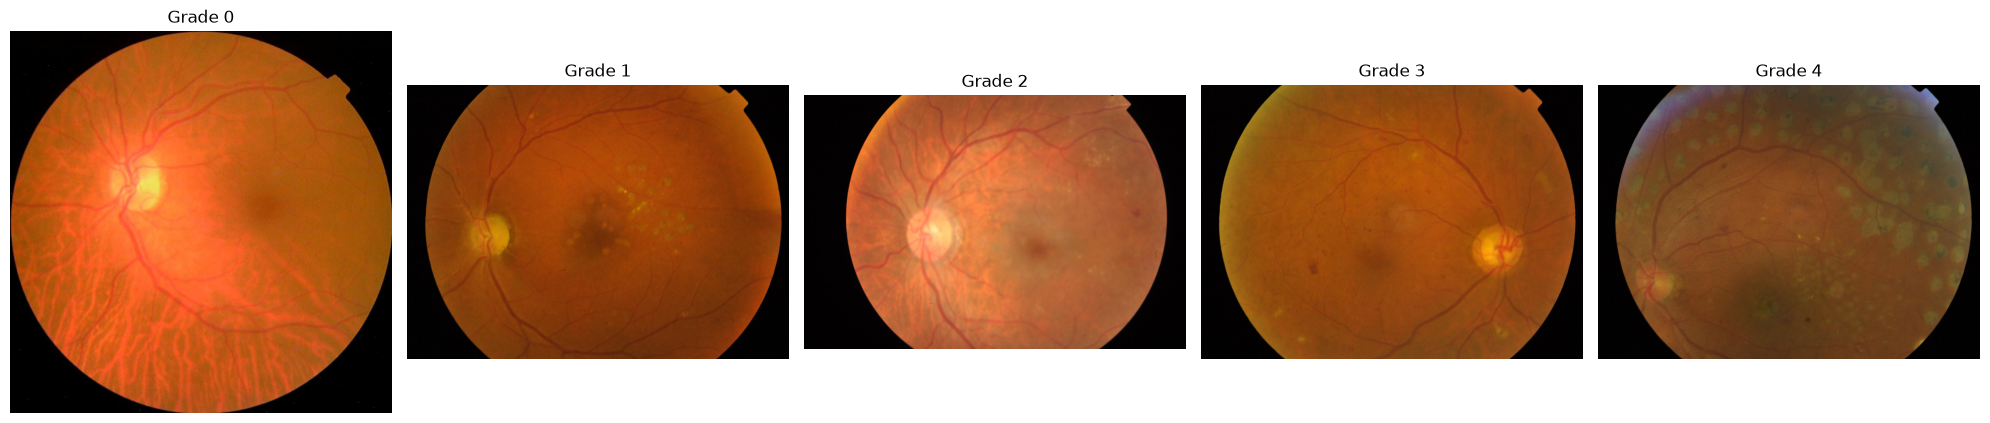

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for grade in range(5):

    sample = df[df["diagnosis"] == grade].sample(
        1,
        random_state=42
    ).iloc[0]

    image_id = sample["id_code"]

    # Find image file
    image_path = None

    for ext in [".png", ".jpg", ".jpeg"]:
        path = os.path.join(TRAIN_DIR, image_id + ext)

        if os.path.exists(path):
            image_path = path
            break

    image = Image.open(image_path)

    axes[grade].imshow(image)
    axes[grade].axis("off")
    axes[grade].set_title(f"Grade {grade}")

plt.tight_layout()
plt.show()


In [14]:
widths = []
heights = []

for image_id in df["id_code"]:

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    image = Image.open(image_path)

    width, height = image.size

    widths.append(width)
    heights.append(height)

print("Number of images:", len(widths))

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))
print("Average width:", round(np.mean(widths), 2))
print("Median width:", np.median(widths))

print("\nMinimum height:", min(heights))
print("Maximum height:", max(heights))
print("Average height:", round(np.mean(heights), 2))
print("Median height:", np.median(heights))

Number of images: 3662
Minimum width: 474
Maximum width: 4288
Average width: 2015.18
Median width: 2144.0

Minimum height: 358
Maximum height: 2848
Average height: 1526.83
Median height: 1536.0


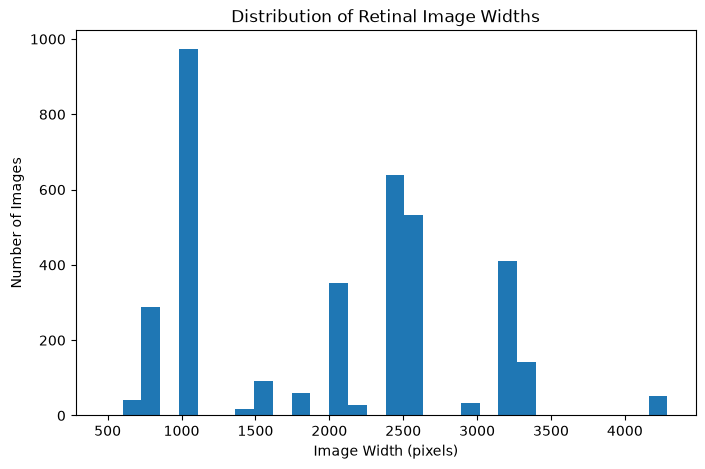

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(widths, bins=30)

plt.xlabel("Image Width (pixels)")
plt.ylabel("Number of Images")
plt.title("Distribution of Retinal Image Widths")

plt.show()

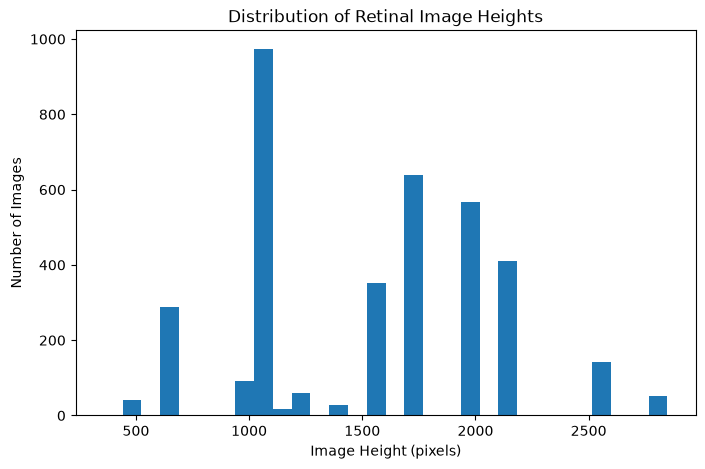

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(heights, bins=30)

plt.xlabel("Image Height (pixels)")
plt.ylabel("Number of Images")
plt.title("Distribution of Retinal Image Heights")

plt.show()

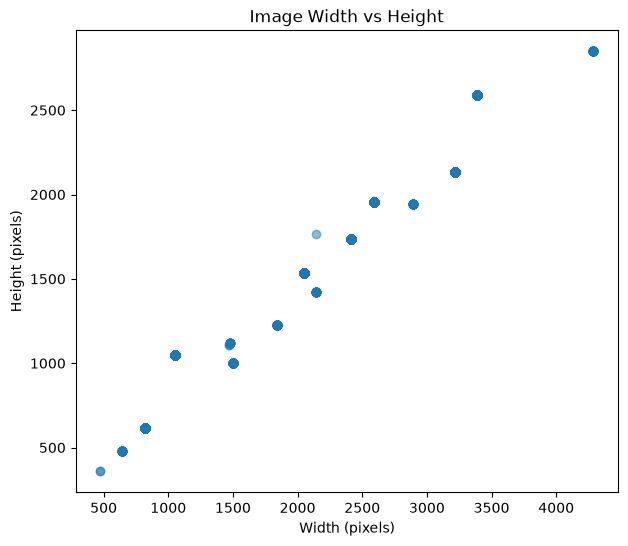

In [17]:
plt.figure(figsize=(7, 6))

plt.scatter(widths, heights, alpha=0.5)

plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Width vs Height")

plt.show()

In [18]:
brightness = []

for image_id in df["id_code"]:

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    image = Image.open(image_path).convert("L")

    pixels = np.array(image)

    mean_brightness = pixels.mean()

    brightness.append(mean_brightness)

df["brightness"] = brightness

df[["id_code", "diagnosis", "brightness"]].head()

,id_code,diagnosis,brightness
0,000c1434d8d7,2,51.388748
1,001639a390f0,4,74.707306
2,0024cdab0c1e,1,66.847438
3,002c21358ce6,0,85.499210
4,005b95c28852,0,22.645165


In [19]:
df["brightness"].describe()


count    3662.000000
mean       66.791908
std        17.977350
min        14.965481
25%        52.072922
50%        68.966786
75%        80.837229
max       129.618169
Name: brightness, dtype: float64

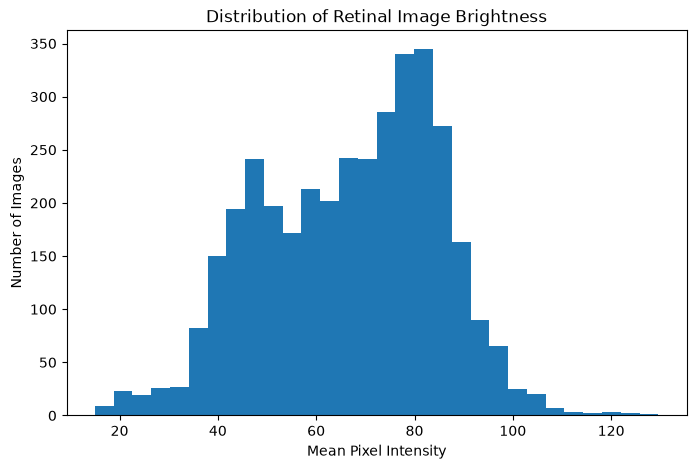

In [20]:
plt.figure(figsize=(8, 5))

plt.hist(df["brightness"], bins=30)

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Distribution of Retinal Image Brightness")

plt.show()

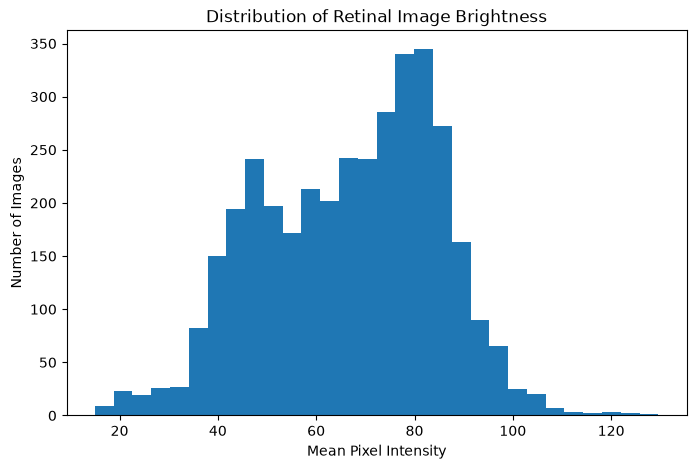

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(df["brightness"], bins=30)

plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Number of Images")
plt.title("Distribution of Retinal Image Brightness")

plt.show()

<Figure size 800x500 with 0 Axes>

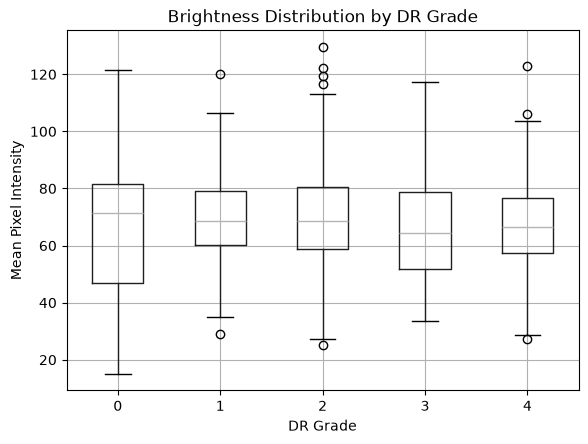

In [22]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="brightness",
    by="diagnosis"
)

plt.xlabel("DR Grade")
plt.ylabel("Mean Pixel Intensity")
plt.title("Brightness Distribution by DR Grade")
plt.suptitle("")

plt.show()

In [23]:
image_id = df.iloc[0]["id_code"]

image_path = os.path.join(
    TRAIN_DIR,
    image_id + ".png"
)

image = Image.open(image_path).convert("RGB")

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (2136, 3216, 3)


In [24]:
gray = np.array(image.convert("L"))

mask = gray > 10

print("Total pixels:", mask.size)
print("Retinal pixels:", mask.sum())

Total pixels: 6869376
Retinal pixels: 5123512


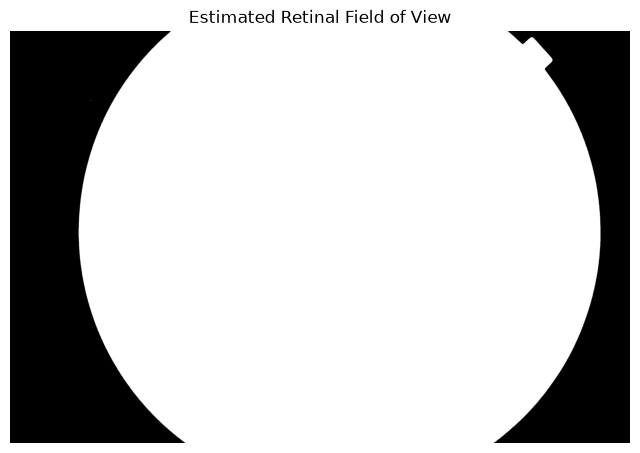

In [25]:
plt.figure(figsize=(8, 6))

plt.imshow(mask, cmap="gray")

plt.axis("off")
plt.title("Estimated Retinal Field of View")

plt.show()

In [26]:
retinal_pixels = gray[mask]

contrast = retinal_pixels.std()

print("Retinal contrast:", contrast)

Retinal contrast: 13.17713734926267


In [27]:
contrasts = []

for image_id in df["id_code"]:

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    image = Image.open(image_path).convert("L")

    gray = np.array(image)

    mask = gray > 10

    retinal_pixels = gray[mask]

    contrast = retinal_pixels.std()

    contrasts.append(contrast)

df["contrast"] = contrasts

df[["id_code", "diagnosis", "brightness", "contrast"]].head()

,id_code,diagnosis,brightness,contrast
0,000c1434d8d7,2,51.388748,13.177137
1,001639a390f0,4,74.707306,9.153033
2,0024cdab0c1e,1,66.847438,12.144463
3,002c21358ce6,0,85.499210,18.703837
4,005b95c28852,0,22.645165,16.522509


In [28]:
df["contrast"].describe()

count    3662.000000
mean       17.618840
std         5.751351
min         5.989045
25%        13.809687
50%        16.572779
75%        19.949043
max        55.855853
Name: contrast, dtype: float64

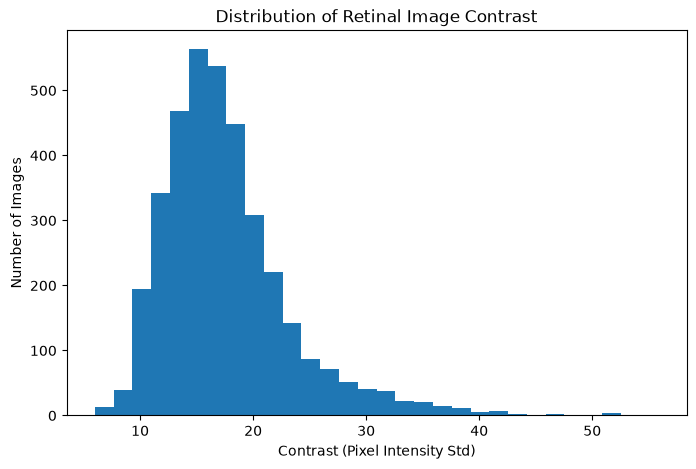

In [29]:
plt.figure(figsize=(8, 5))

plt.hist(df["contrast"], bins=30)

plt.xlabel("Contrast (Pixel Intensity Std)")
plt.ylabel("Number of Images")
plt.title("Distribution of Retinal Image Contrast")

plt.show()

<Figure size 800x500 with 0 Axes>

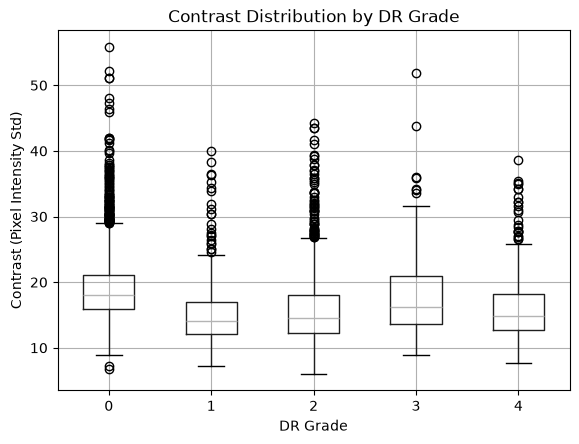

In [30]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="contrast",
    by="diagnosis"
)

plt.xlabel("DR Grade")
plt.ylabel("Contrast (Pixel Intensity Std)")
plt.title("Contrast Distribution by DR Grade")
plt.suptitle("")

plt.show()

In [31]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [32]:
sharpness_values = []

for image_id in df["id_code"]:

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    image = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Resize for faster EDA processing
    image = cv2.resize(
        image,
        (512, 512)
    )

    # Estimate retinal field of view
    mask = image > 10

    # Calculate Laplacian
    laplacian = cv2.Laplacian(
        image,
        cv2.CV_64F
    )

    # Only use pixels inside the retinal field
    retinal_laplacian = laplacian[mask]

    # Variance of Laplacian = sharpness measure
    sharpness = retinal_laplacian.var()

    sharpness_values.append(sharpness)

df["sharpness"] = sharpness_values

df[
    ["id_code", "diagnosis", "brightness", "contrast", "sharpness"]
].head()

,id_code,diagnosis,brightness,contrast,sharpness
0,000c1434d8d7,2,51.388748,13.177137,95.420244
1,001639a390f0,4,74.707306,9.153033,58.074247
2,0024cdab0c1e,1,66.847438,12.144463,90.114004
3,002c21358ce6,0,85.499210,18.703837,112.612866
4,005b95c28852,0,22.645165,16.522509,119.842416


In [33]:
df["sharpness"].describe()

count    3662.000000
mean       96.747334
std        47.804983
min        11.848106
25%        66.792366
50%        95.584900
75%       123.301250
max       417.682751
Name: sharpness, dtype: float64

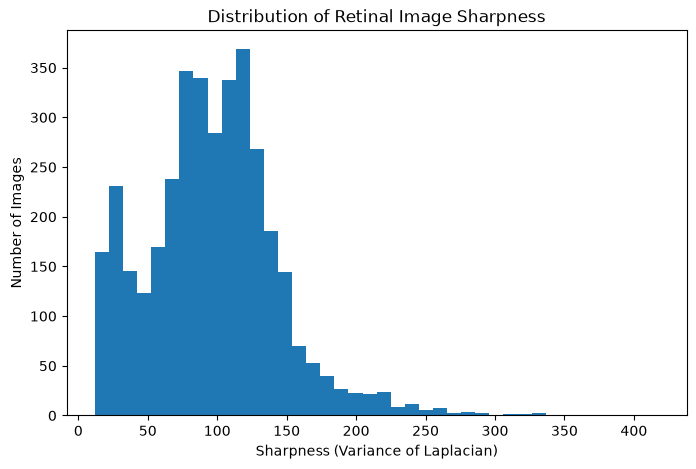

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["sharpness"],
    bins=40
)

plt.xlabel("Sharpness (Variance of Laplacian)")
plt.ylabel("Number of Images")
plt.title("Distribution of Retinal Image Sharpness")

plt.show()

<Figure size 800x500 with 0 Axes>

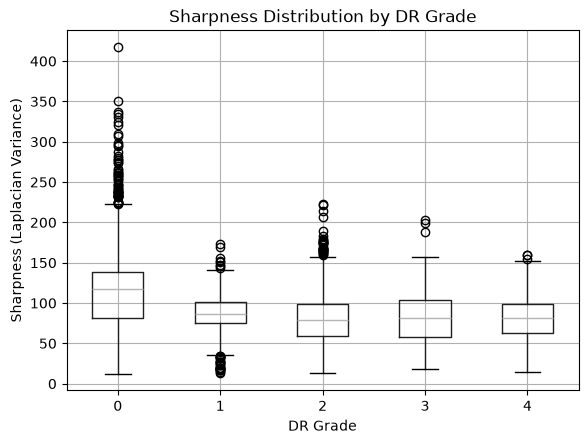

In [35]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="sharpness",
    by="diagnosis"
)

plt.xlabel("DR Grade")
plt.ylabel("Sharpness (Laplacian Variance)")
plt.title("Sharpness Distribution by DR Grade")
plt.suptitle("")

plt.show()

In [36]:
blurriest = df.nsmallest(
    10,
    "sharpness"
)[
    ["id_code", "diagnosis", "sharpness"]
]

blurriest

,id_code,diagnosis,sharpness
563,27f82ada84ac,0,11.848106
1799,7ef5ff774a48,1,12.725536
1071,4c60f6fcea75,0,12.885126
1178,521b5377a727,0,12.899940
1678,76cab26493f1,0,13.078973
374,1b8701231c8f,0,13.313850
1695,77baa08a1345,2,13.715775
2341,a3bd2e034614,0,13.754002
1882,84b472c49cfa,0,13.924819
2319,a26f50218b84,0,14.097969


In [37]:
sharpest = df.nlargest(
    10,
    "sharpness"
)[
    ["id_code", "diagnosis", "sharpness"]
]

sharpest

,id_code,diagnosis,sharpness
1147,50915e2329a1,0,417.682751
1308,5b1c4cefeb24,0,350.984786
2824,c3b15bf9b4bc,0,336.444243
720,33d72035c27a,0,334.708017
1218,54334705a34d,0,330.939697
3114,d866c26d76f0,0,324.449092
2656,b82dfa63a75f,0,320.497743
1229,54f57cf26126,0,309.550912
312,17d7d6b092f4,0,307.342489
2095,92fcf50b3562,0,298.902058


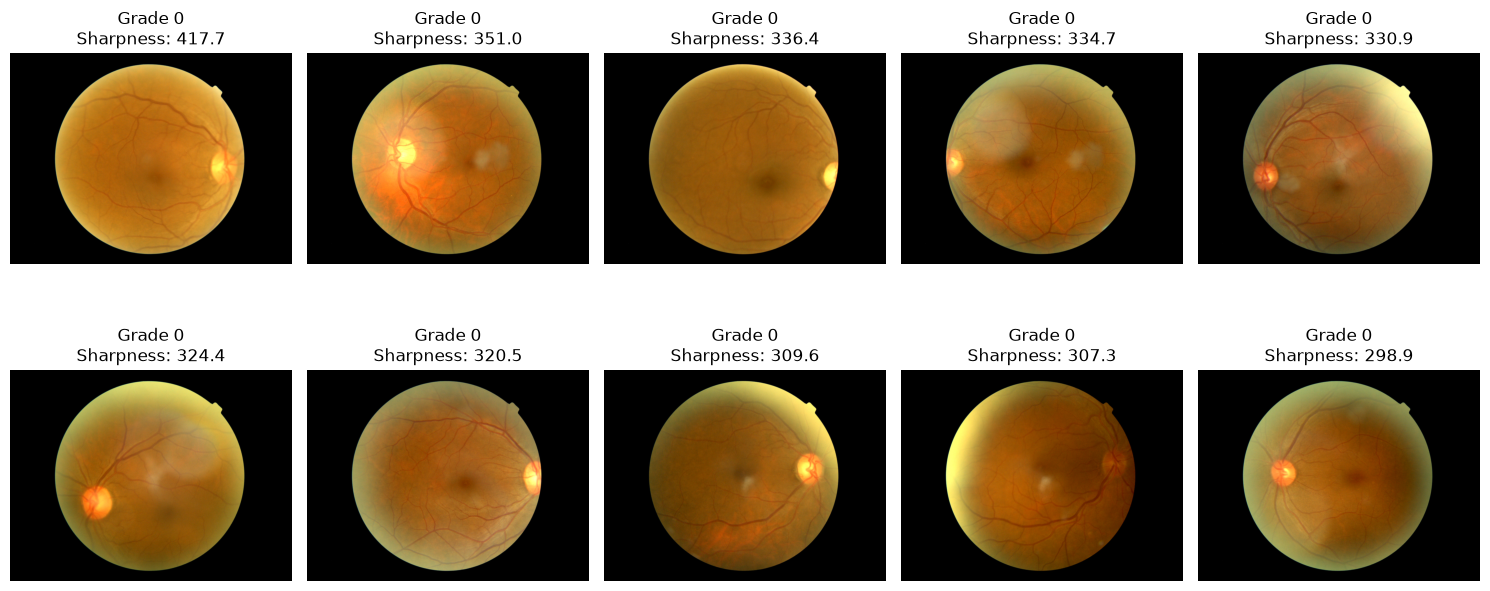

In [38]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15, 7)
)

for ax, (_, row) in zip(
    axes.ravel(),
    sharpest.iterrows()
):

    image_id = row["id_code"]

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        f"Grade {row['diagnosis']}\n"
        f"Sharpness: {row['sharpness']:.1f}"
    )

plt.tight_layout()
plt.show()

In [39]:
eda_metrics = df[
    [
        "id_code",
        "diagnosis",
        "brightness",
        "contrast",
        "sharpness"
    ]
]

eda_metrics.to_csv(
    r"D:\diabetic\outputs\eda\image_quality_metrics.csv",
    index=False
)

print("Saved EDA metrics.")

Saved EDA metrics.


In [40]:
brightness_low = df["brightness"].quantile(0.05)
brightness_high = df["brightness"].quantile(0.95)

contrast_low = df["contrast"].quantile(0.05)
contrast_high = df["contrast"].quantile(0.95)

sharpness_low = df["sharpness"].quantile(0.05)
sharpness_high = df["sharpness"].quantile(0.95)

print("Brightness:")
print("  Low threshold :", round(brightness_low, 2))
print("  High threshold:", round(brightness_high, 2))

print("\nContrast:")
print("  Low threshold :", round(contrast_low, 2))
print("  High threshold:", round(contrast_high, 2))

print("\nSharpness:")
print("  Low threshold :", round(sharpness_low, 2))
print("  High threshold:", round(sharpness_high, 2))

Brightness:
  Low threshold : 37.85
  High threshold: 92.54

Contrast:
  Low threshold : 10.59
  High threshold: 28.83

Sharpness:
  Low threshold : 22.66
  High threshold: 175.68


In [41]:
df["low_brightness"] = df["brightness"] < brightness_low
df["low_contrast"] = df["contrast"] < contrast_low
df["low_sharpness"] = df["sharpness"] < sharpness_low

In [42]:
df["quality_flag"] = (
    df["low_brightness"] |
    df["low_contrast"] |
    df["low_sharpness"]
)

In [43]:
print("Images with at least one quality flag:",
      df["quality_flag"].sum())

print("Percentage:",
      round(df["quality_flag"].mean() * 100, 2), "%")

Images with at least one quality flag: 492
Percentage: 13.44 %


In [44]:
quality_counts = {
    "Low brightness": df["low_brightness"].sum(),
    "Low contrast": df["low_contrast"].sum(),
    "Low sharpness": df["low_sharpness"].sum()
}

quality_counts

{'Low brightness': np.int64(184),
 'Low contrast': np.int64(184),
 'Low sharpness': np.int64(184)}

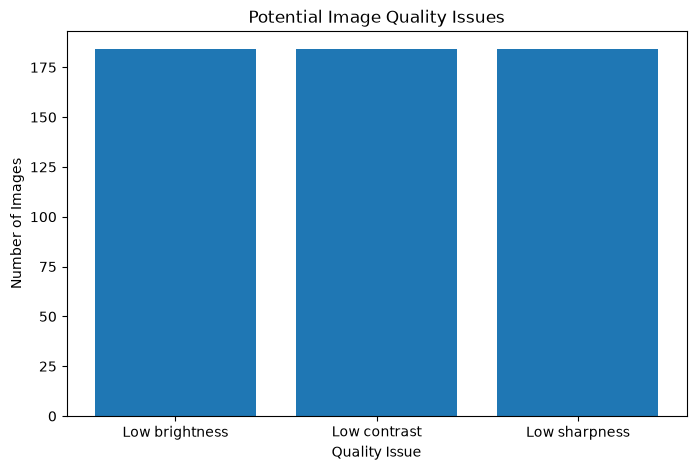

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    quality_counts.keys(),
    quality_counts.values()
)

plt.xlabel("Quality Issue")
plt.ylabel("Number of Images")
plt.title("Potential Image Quality Issues")

plt.show()

In [46]:
df["quality_issue_count"] = (
    df["low_brightness"].astype(int)
    + df["low_contrast"].astype(int)
    + df["low_sharpness"].astype(int)
)

df[
    [
        "id_code",
        "diagnosis",
        "brightness",
        "contrast",
        "sharpness",
        "quality_issue_count"
    ]
].sort_values(
    "quality_issue_count",
    ascending=False
).head(20)

,id_code,diagnosis,brightness,contrast,sharpness,quality_issue_count
3024,d25b8a8ad3c4,2,33.102925,7.579404,18.552037,3
3600,fb767cea406c,0,36.582833,10.015476,14.330486,3
2621,b6304c545f95,2,27.137762,10.222770,16.381486,3
2679,b963a11638f2,0,35.735357,10.195515,15.161744,3
3237,e1418d28d668,2,29.250100,7.957946,16.000914,3
1695,77baa08a1345,2,25.332686,7.006708,13.715775,3
1233,5548a7961a3e,1,28.987866,10.080741,19.432974,3
788,387138ddf43d,0,34.140300,9.884173,15.865245,3
2717,bc23f74e14dd,2,32.650973,14.089413,19.437279,2
2319,a26f50218b84,0,35.867653,16.518953,14.097969,2


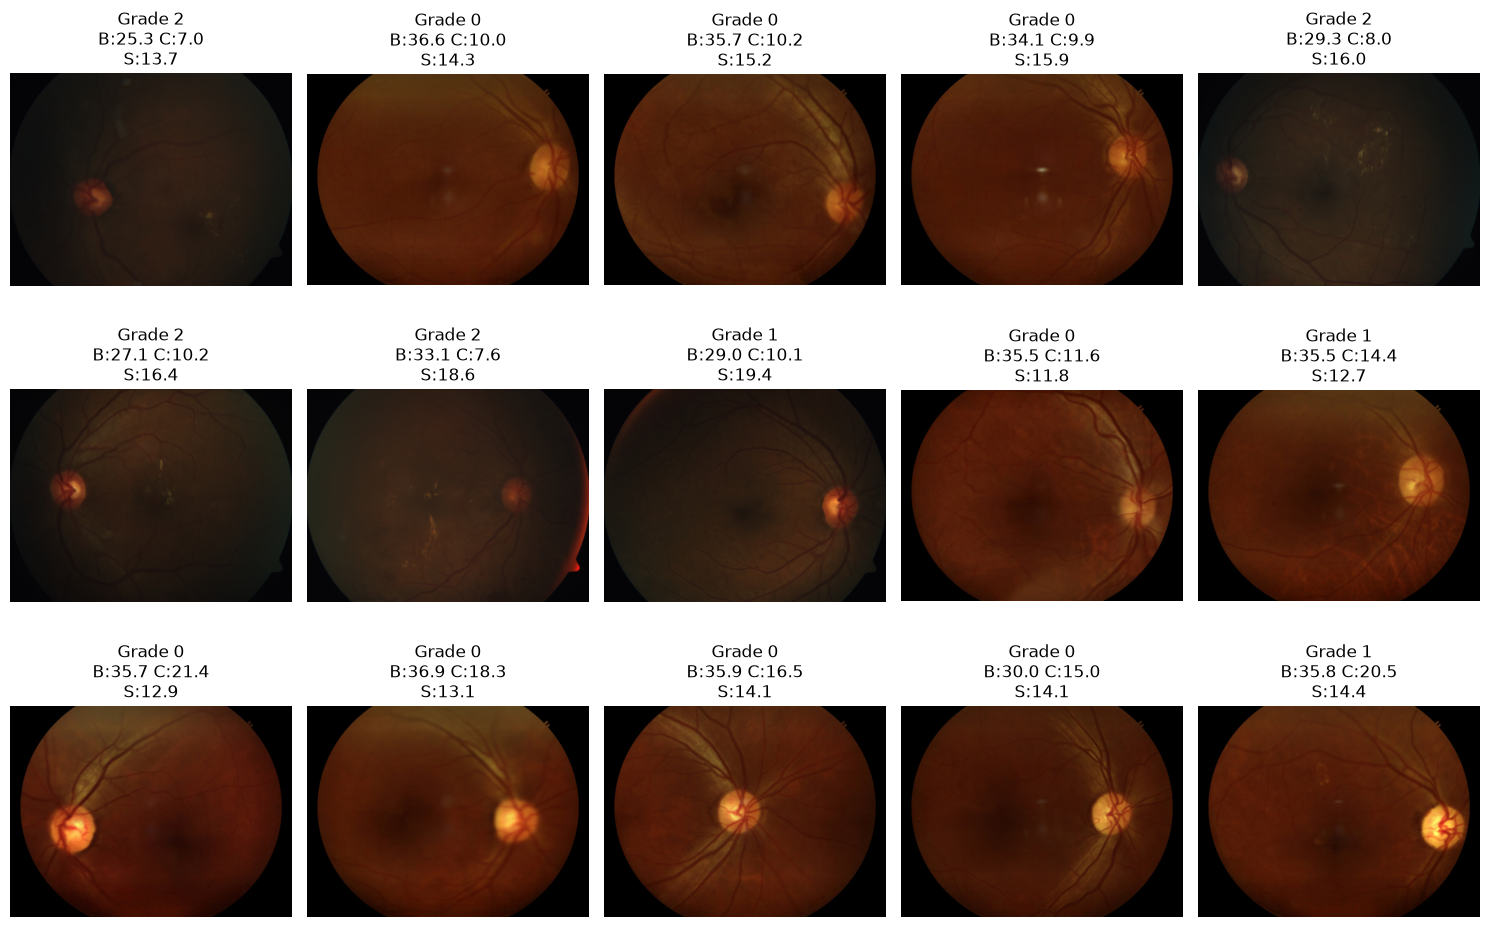

In [47]:
suspicious = df.sort_values(
    ["quality_issue_count", "sharpness"],
    ascending=[False, True]
).head(15)

fig, axes = plt.subplots(
    3,
    5,
    figsize=(15, 10)
)

for ax, (_, row) in zip(
    axes.ravel(),
    suspicious.iterrows()
):

    image_id = row["id_code"]

    image_path = os.path.join(
        TRAIN_DIR,
        image_id + ".png"
    )

    image = Image.open(image_path)

    ax.imshow(image)
    ax.axis("off")

    ax.set_title(
        f"Grade {row['diagnosis']}\n"
        f"B:{row['brightness']:.1f} "
        f"C:{row['contrast']:.1f}\n"
        f"S:{row['sharpness']:.1f}"
    )

plt.tight_layout()
plt.show()

In [48]:
quality_by_grade = df.groupby("diagnosis")[
    [
        "low_brightness",
        "low_contrast",
        "low_sharpness"
    ]
].mean() * 100

quality_by_grade.round(2)

,low_brightness,low_contrast,low_sharpness
diagnosis,,,
0,7.31,0.94,6.37
1,1.62,7.30,2.97
2,2.30,10.91,4.40
3,4.66,4.66,3.11
4,4.75,7.46,2.71


In [49]:
eda_metrics = df[
    [
        "id_code",
        "diagnosis",
        "brightness",
        "contrast",
        "sharpness",
        "low_brightness",
        "low_contrast",
        "low_sharpness",
        "quality_flag",
        "quality_issue_count"
    ]
]

output_path = r"D:\diabetic\outputs\eda\image_quality_metrics.csv"

eda_metrics.to_csv(
    output_path,
    index=False
)

print(f"Saved to: {output_path}")

Saved to: D:\diabetic\outputs\eda\image_quality_metrics.csv
